<a href="https://colab.research.google.com/github/znr6s28ynr-maker/Econometrics-Work/blob/main/Heteroscedasticity%2C_Variance_of_Estimators%2C_and_Maximum_Likelihood_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Heteroscedasticity and Slope Estimate Variance

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Simulate independent variable (x), 100 numbers between 1 and 10
X = np.linspace(1, 10, 100).reshape(-1, 1)

# True intercept and slope
intercept = 3
slope = 5

#true population regression line
y_true = intercept + slope * X.flatten()



# Homoscedastic errors (constant variance)
errors_homo = np.random.normal(0, 2.5, 100) #100 random errors from normal distribution w mean 0, std 5

# Heteroscedastic errors (variance increases with x)
scale = 5 / np.sqrt(np.mean(X.flatten()**2))
errors_hetero = np.random.normal(0, 3, 100) * X.flatten() * scale #scaling possible heteroscedastic errors so avg of std^2 = 25, so we can tell whether it's heteroscedasticity that's affecting variance in slope estimates



# Simulate dependent variable (y) with homoscedastic errors
y_homo = y_true + errors_homo

# Simulate dependent variable (y) with heteroscedastic errors
y_hetero = y_true + errors_hetero



#fitting regressions
model_homo = LinearRegression()
model_hetero = LinearRegression()

model_homo.fit(X, y_homo)
model_hetero.fit(X, y_hetero)

print("Homoscedastic slope:", model_homo.coef_[0])
print("Heteroscedastic slope:", model_hetero.coef_[0])




Homoscedastic slope: 5.038314631490712
Heteroscedastic slope: 4.887192281820933


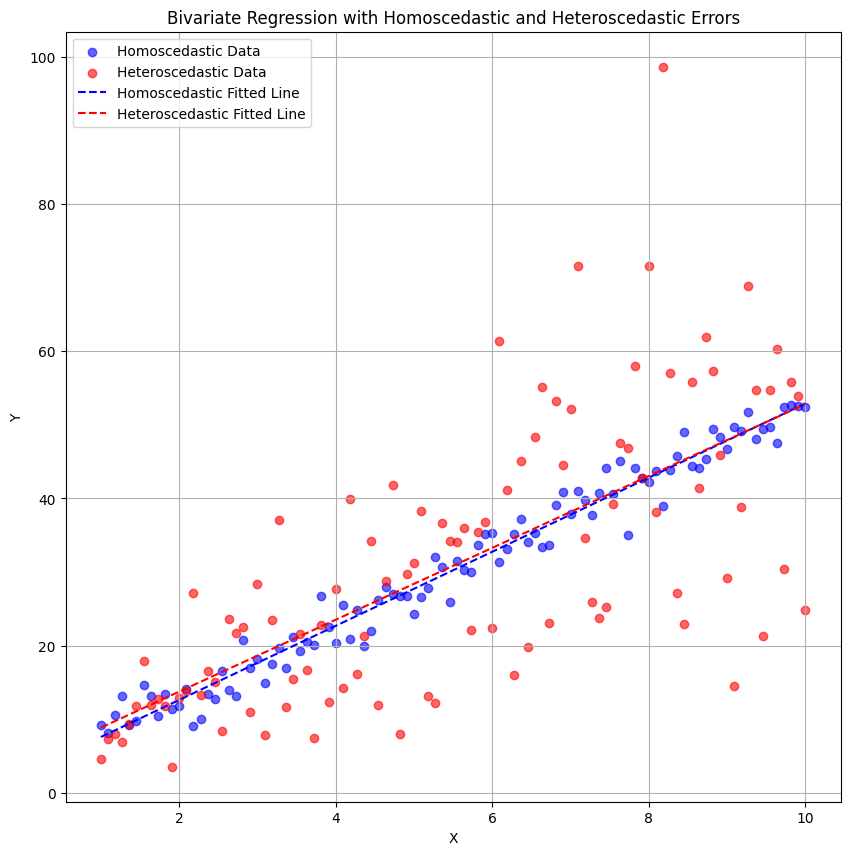

In [3]:
#
y_homo_pred = model_homo.predict(X)
y_hetero_pred = model_hetero.predict(X)

# Plotting the homo and hetero generated data:
plt.figure(figsize=(10, 10))

# Plot homoscedastic data
plt.scatter(X, y_homo, color='blue', alpha=0.6, label='Homoscedastic Data')
# Plot heteroscedastic data
plt.scatter(X, y_hetero, color='red', alpha=0.6, label='Heteroscedastic Data')


# Plot the fitted regression lines
plt.plot(X, y_homo_pred, color='blue', linestyle='--', label='Homoscedastic Fitted Line')
plt.plot(X, y_hetero_pred, color='red', linestyle='--', label='Heteroscedastic Fitted Line')


# Adding labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bivariate Regression with Homoscedastic and Heteroscedastic Errors')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

Homoscedastic variance: 0.03618249020638969
Heteroscedastic variance: 0.04191036397401006

Homoscedastic standard deviation: 0.19021695562275642
Heteroscedastic standard deviation: 0.20472020900245794


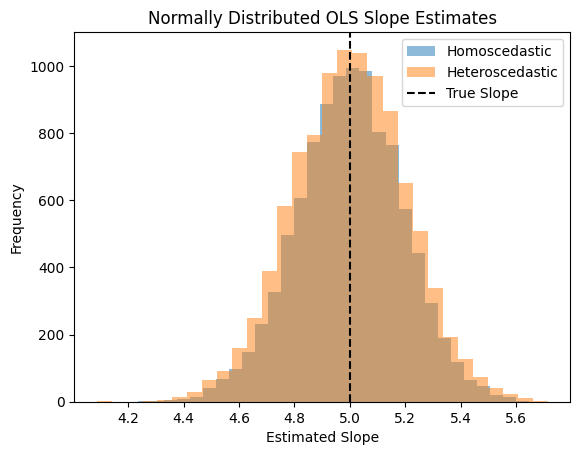

In [4]:

#running Monte Carlo sim: running the OLS 10000 times over the data and plotting histogram of slope estimates

homo_slopes = []
hetero_slopes = []

for i in range(10000):

  #generating new random errors
  errors_homo = np.random.normal(0, 5, 100)
  errors_hetero = np.random.normal(0, 1, 100) * X.flatten() * scale

  #generating new observed Y values
  y_homo = y_true + errors_homo
  y_hetero = y_true + errors_hetero

  #fitting the regressions
  model_homo.fit(X, y_homo)
  model_hetero.fit(X, y_hetero)

  #saving slopes in lists
  homo_slopes.append(model_homo.coef_[0])
  hetero_slopes.append(model_hetero.coef_[0])

#calculating variance and standard deviation

homo_slopes_var = np.var(homo_slopes, ddof=1)
hetero_slopes_var = np.var(hetero_slopes, ddof=1)

print("Homoscedastic variance:",
      homo_slopes_var)
print("Heteroscedastic variance:",
      hetero_slopes_var)

print()

print("Homoscedastic standard deviation:",
      np.std(homo_slopes, ddof=1))
print("Heteroscedastic standard deviation:",
      np.std(hetero_slopes, ddof=1))

#plotting results
plt.hist(homo_slopes, bins=30, alpha=0.5, label="Homoscedastic")

plt.hist(hetero_slopes, bins=30, alpha=0.5, label="Heteroscedastic")

plt.axvline(5, color="black", linestyle="--", label="True Slope")

plt.xlabel("Estimated Slope")
plt.ylabel("Frequency")
plt.title("Normally Distributed OLS Slope Estimates")

plt.legend()
plt.show()


In [5]:
ratio = ((hetero_slopes_var / homo_slopes_var) - 1) * 100

percentage = round(ratio, 2)
print("In this simulation, the heteroscedastic data produced slope estimates with", percentage,"% greater variance than the homoscedastic data." )



In this simulation, the heteroscedastic data produced slope estimates with 15.83 % greater variance than the homoscedastic data.


## Unbiased Linear Estimators and Coefficient Variance

The OLS models the data by minimizing the sum of squared residuals. As we saw in a previous assignment, it is unbiased because

\begin{equation}
E[\hat{\beta}] = \beta
\end{equation}

Another unbiased approach would be to estimate the slope by using only two of the data points, rather than all the available data, as OLS does. (My stats professor suggested this in a lecture last week on bias and variance!) Our estimator of the slope $\beta_1$ could be:

\begin{equation}
\hat{\beta_1} = \frac{y_1 - y_2}{x_1 - x_2}
\end{equation}

which is basically the point slope formula. This estimator is also unbiased because $E[\hat{\beta_1}] = \beta_1$:

If we substitute the population model into the estimator, we get:  

\begin{equation}
\hat{\beta_1} = \frac{(\beta_0 + \beta_1x_1+\epsilon_1) - (\beta_0 + \beta_1x_2 + \epsilon_2)}{x_1 - x_2}
\end{equation}

Simplifying:

\begin{equation}
\hat{\beta_1} = \frac{(\beta_1x_1+\epsilon_1) - (\beta_1x_2+\epsilon_2)}{x_1 - x_2}
\end{equation}

\begin{equation}
\hat{\beta_1} = \frac{\beta_1(x_1-x_2) + \epsilon_1 - \epsilon_2}{x_1 - x_2}
\end{equation}

\begin{equation}
\hat{\beta_1} = \frac{\beta_1}{(x_1-x_2)} + \frac{\epsilon_1 - \epsilon_2}{(x_1-x_2)}
\end{equation}

\begin{equation}
\hat{\beta_1} = \beta_1 + \frac{\epsilon_1 - \epsilon_2}{(x_1-x_2)}
\end{equation}

Taking the expected values:

\begin{equation}
E[\hat{\beta_1}] = E[\beta_1] + E[\frac{\epsilon_1 - \epsilon_2}{(x_1-x_2)}]
\end{equation}

If $E[\epsilon_i] = 0$ according to the assumptions, then we do indeed end up with the following equation that shows that $\hat{\beta_1}$ is an unbiased estimator of the population mean:

\begin{equation}
E[\hat{\beta_1}] = \beta_1
\end{equation}

Because the data points could potentially be all over the place, we could get any number of slopes if we took any 2 random data points over and over and used them to estimate the slope. It seems almost certain that variance in the OLS model will be smaller. To demonstrate, I'll tweak the example I created in the second homework assignment about Starbucks barista salaries. Here is the data without any fit lines:

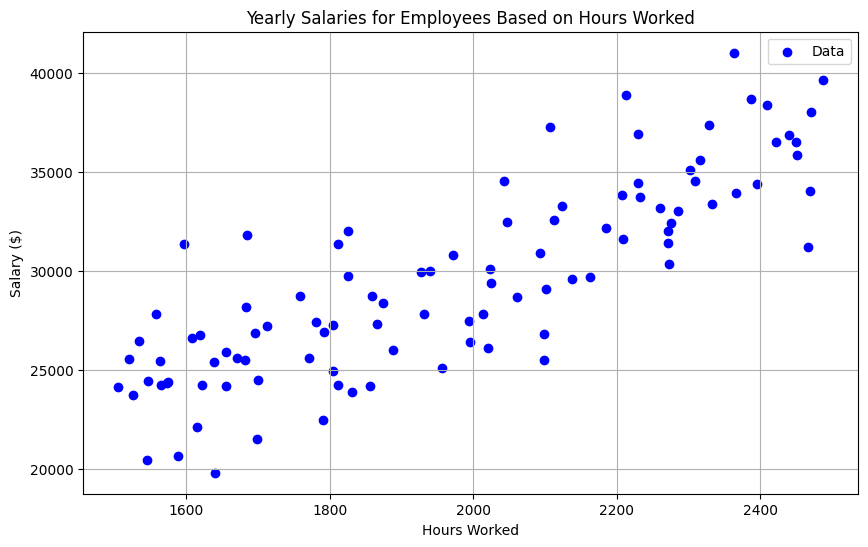

In [6]:
from sklearn.linear_model import LinearRegression

# Set seed for reproducibility
np.random.seed(42)

# Number of observations
n = 100

# Simulate hours worked
hours = np.random.uniform(1500, 2500, n)  # Between 1500 and 2500 hours worked

# Define population coefficient
beta_1 = 15  # slope with respect to salary

# Error term
epsilon = np.random.normal(0, 3000, n)  # Random noise

# Simulate salary
salary = beta_1 * hours + epsilon

#fit model
model = LinearRegression().fit(hours.reshape(-1, 1), salary)

# Get the estimated intercept
intercept = model.intercept_

# Plotting the data
plt.figure(figsize=(10, 6))
plt.scatter(hours, salary, color='blue', label='Data')

# Adding labels and title
plt.xlabel('Hours Worked')
plt.ylabel('Salary ($)')
plt.title('Yearly Salaries for Employees Based on Hours Worked')
plt.legend()
plt.grid(True)
plt.show()

Here it is with the OLS and GMM regression lines:

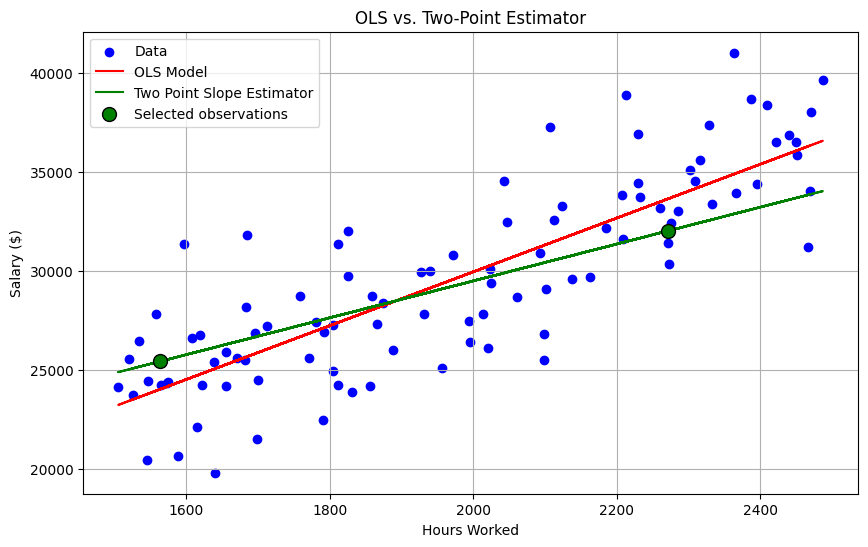

In [7]:
# Set seed for reproducibility
np.random.seed(42)

# Number of observations
n = 100

# Simulate hours worked
hours = np.random.uniform(1500, 2500, n)

# Define population coefficient
beta_1 = 15

# Error term
epsilon = np.random.normal(0, 3000, n)

# Simulate salary
salary = beta_1 * hours + epsilon

# Fit OLS model
model = LinearRegression().fit(hours.reshape(-1, 1), salary)

# Get estimated coefficients
intercept_ols = model.intercept_
slope_ols = model.coef_[0]


i, j, = np.random.choice(n, size=2, replace=False)
slope_two_point = (salary[j] - salary[i]) / (hours[j] - hours[i])
intercept_two_point = salary[i] - slope_two_point * hours[i]

# Plotting the data
plt.figure(figsize=(10, 6))
plt.scatter(hours, salary, color='blue', label='Data')


# Plotting OLS model
plt.plot(
    hours,
    intercept_ols + slope_ols * hours,
    color='red',
    label='OLS Model'
)

# Plotting 2-point slope model
plt.plot(
    hours,
    intercept_two_point + slope_two_point * hours,
    color='g',
    label='Two Point Slope Estimator'
)

# Highlight the two randomly selected observations
plt.scatter(
    hours[[i, j]],
    salary[[i, j]],
    color='green',
    s=100,
    edgecolor='black',
    zorder=5,
    label='Selected observations'
)

plt.xlabel('Hours Worked')
plt.ylabel('Salary ($)')
plt.title('OLS vs. Two-Point Estimator')
plt.legend()
plt.grid(True)
plt.show()



Obviously if we were to run this simulation over and over again, we would get a very large variety of different slopes, especially in comparison to the OLS model. If there were only 2 data points, then the OLS model would generate ths same coefficients as the 2-point model, but as the number of samples goes up, it makes sense that we are going to see more variation in the slopes of the 2-point estimate.

## An Origin Story: The Likelihood Function of Linear Regressions

The likelihood function for a linear regression, if we assume that


*   the errors are normally distributed and
*   the variance is $\sigma^2$,

is:

\begin{equation}
L(\beta_0, \beta_1, \sigma^2; y_i, x_i) = (2 \pi \sigma^2)^{-\frac{n}{2}}e^{-\frac{1}{2\sigma^2}\sum_{i=1}^n(y_i - \beta_0 - \beta_1x_i)^2}
\end{equation}

This function is clearly a variation of the gaussian normal distribution pdf:

\begin{equation}
f(x | \mu, \sigma^2) = (2 \pi \sigma^2)^{-\frac{1}{2}}e^{-\frac{1}{2}(\frac{x-\mu}{\sigma})^2}
\end{equation}

In fact, we can get to the likelihood function quite easily, first by noticing that the only significant difference between the functions is the $(y_i - \beta_0 - \beta_1x_i)$ that appears the likelihood function and $(x-\mu)$ in the normal distribution pdf. Both terms are measuring a difference: in the likelihood function, we are measuring the difference between the dependent variable and the value of the parameters (the error term). In the normal distribution, we are measuring the distance between the x value and the mean (in a way, this could be thought of as a sort of  "error" since the mean represents the expected value).

Since $(y_i - \beta_0 - \beta_1x_i) = \epsilon_i$, we can substitute that into the normal pdf in place of $(x-\mu)$ to get:

\begin{equation}
(2 \pi \sigma^2)^{-\frac{1}{2}}e^{-\frac{1}{2}(\frac{(y_i - \beta_0 - \beta_1x_i)}{\sigma})^2}
\end{equation}

We can square the error term and the $\sigma$ in the exponent and pull $\frac{1}{\sigma^2}$ out to multiply with the $\frac{1}{2}$, which gives us:

\begin{equation}
(2 \pi \sigma^2)^{-\frac{1}{2}}e^{-\frac{1}{2\sigma^2}(y_i - \beta_0 - \beta_1x_i)^2}
\end{equation}

If all observations in the sample are independent, then we can calculate the combined likelihood by multiplying all the individual probabilities  together:

\begin{equation}
\prod_{i=1}^n(2 \pi \sigma^2)^{-\frac{1}{2}}e^{-\frac{1}{2\sigma^2}(y_i - \beta_0 - \beta_1x_i)^2}
\end{equation}

That product, when distributed, is:

\begin{equation}
\prod_{i=1}^n(2 \pi \sigma^2)^{-\frac{1}{2}}
\prod_{i=1}^ne^{-\frac{1}{2\sigma^2}(y_i - \beta_0 - \beta_1x_i)^2}
\end{equation}



\begin{equation}
(2 \pi \sigma^2)^{-\frac{n}{2}}e^{-\frac{1}{2\sigma^2}\sum_{i=1}^n(y_i - \beta_0 - \beta_1x_i)^2}
\end{equation}

which is the likelihood function!

As I understand it, the normal distribution is a variation of the binomial distribution (and of some other distributions, I believe) as $n$ gets increasingly large. In my statistics class last year, our professor challenged us to derive the normal distribution from the binomial. I did it, (with some help!) and it was really amazing to see how it all came together. Because I worked (for days!) on that derivation, I can be pretty specific about where parts of this likelihood function (and of the normal distribution) can come from:

The binomial distribution involves a lot of factorials, so you can use the Stirling approximation of factorials to manipulate the terms more easily. That approximation is:
\begin{equation}
m! \sim \sqrt{2\pi m}(\frac{m}{e})^m
\end{equation}

which is one way to get the $2\pi$ in the normal distribution pdf.

There are other ways to arrive at these coefficients, but for me, the $\frac{1}{2}$s in my derivation came from taking the log of the function in order to simplify differentiation, which turns the square root signs into $\frac{1}{2}$s.

The $e$ appeared at the end when I "undid" those logs.

As for the other terms, $(y_i - \beta_0 - \beta_1x_i)$ is the error of the population regression line, and $\sigma^2$ is its variance.

## The OLS Estimator and the Linear Regression MLE

The OLS estimator finds the coefficients of the model by minimizing the sum of squared residuals (SSR) and the Linear Regression MLE finds them by maximizing the likelihood function. Both methods result in the same coefficients when the assumptions about distribution of the errors prove true.

To minimize the SSR with OLS, you take the derivative of the expression with respect to $\beta_0$ and $\beta_1$:

\begin{equation}
\frac{\partial SSR}{\partial b_0} = \frac{\partial SSR}{\partial b_0}\sum_{i=1}^n(y_i - b_0 - b_1x_i)^2
\end{equation}

\begin{equation}
\frac{\partial SSR}{\partial b_1} = \frac{\partial SSR}{\partial b_1}\sum_{i=1}^n(y_i - b_0 - b_1x_i)^2
\end{equation}

We worked these through in previous homework assignments. Once you do all the math, you end up with the estimators:

\begin{equation}
\hat{\beta_0} = \bar{y} - b_1\bar{x}
\end{equation}

\begin{equation}
\hat{\beta_1} = \frac{\sum_{i=1}^n(y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n(x_i - \bar{x})^2}
=
\frac{COV(x, y)}{VAR(x)}
\end{equation}

To maximize the likelihood function, we similarly have to take the derivative. It's easiest to do if you take the log of the function first:

\begin{equation}
LL(\beta_0, \beta_1, \sigma^2; x_i, y_i) = log((2 \pi \sigma^2)^{-\frac{n}{2}}e^{-\frac{1}{2\sigma^2}\sum_{i=1}^n(y_i - \beta_0 - \beta_1x_i)^2})
\end{equation}

Using properties of logs, we get:

\begin{equation}
LL(\beta_0, \beta_1, \sigma^2; x_i, y_i) = -\frac{n}{2}log(2\pi) -\frac{n}{2}log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)^2
\end{equation}

We then differentiate the function with respect to $\beta_0$ and $\beta_1$:

Starting with $\beta_0$:

\begin{equation}
\frac{\partial}{\partial\beta_0} = \frac{\partial}{\partial\beta_0} (-\frac{n}{2}log(2\pi) -\frac{n}{2}log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)^2)
\end{equation}

\begin{equation}
\frac{\partial}{\partial\beta_0} = \frac{1}{\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)
\end{equation}

We can set the result to 0 and rearrange to find the normal equations:

\begin{equation}
0 = \frac{1}{\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)
\end{equation}

\begin{equation}
0 = \sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)
\end{equation}

\begin{equation}
0 = \sum_{i+1}^ny_i-\sum_{i+1}^n\beta_0-\sum_{i+1}^n\beta_1x_i
\end{equation}

\begin{equation}
\sum_{i+1}^ny_i = n\beta_0 +\sum_{i+1}^n\beta_1x_i
\end{equation}

Divide by n and that gives the normal equation:

\begin{equation}
\bar{y} = \beta_0 +\beta_1\bar{x}
\end{equation}

Then, when we solve for $\beta_0$, we get:

\begin{equation}
\hat{\beta_0} = \bar{y}-\beta_1\bar{x}
\end{equation}


For $\beta_1$:

\begin{equation}
\frac{\partial}{\partial\beta_1} = \frac{\partial}{\partial\beta_1} (-\frac{n}{2}log(2\pi) -\frac{n}{2}log(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)^2)
\end{equation}

\begin{equation}
\frac{\partial}{\partial\beta_1} = \frac{1}{\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)x_i
\end{equation}

We can set the result to 0 and rearrange to find the normal equations:

\begin{equation}
0 = \frac{1}{\sigma^2}\sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)x_i
\end{equation}

\begin{equation}
0 = \sum_{i+1}^n(y_i-\beta_0-\beta_1x_i)x_i
\end{equation}

\begin{equation}
0 = \sum_{i+1}^ny_ix_i-\sum_{i+1}^n\beta_0x_i-\sum_{i+1}^n\beta_1x_i^2
\end{equation}

\begin{equation}
\sum_{i+1}^ny_ix_i = \beta_0\sum_{i+1}^nx_i +\beta_1\sum_{i+1}^nx_i^2
\end{equation}



Then, when we solve for $\beta_1$, we substitute $\bar{y_i}-\beta_1\bar{x}$ for $\hat{\beta_0}$ and then do what we did in a previous homework assignment and solve for $\beta_1$. It's a whole process that ends with:

\begin{equation}
\hat{\beta_1} = \frac{\sum_{i=1}^n(y_i - \bar{y})(x_i - \bar{x})}{\sum_{i=1}^n(x_i - \bar{x})^2}
=
\frac{COV(x, y)}{VAR(x)}
\end{equation}

The estimators produced by the MLE and the OLS prove to be the same! It's important to remember though, that this only happens when the errors are normally distributed with a variance of $\sigma^2$.


## OLS vs MLE Usefulness

It seems to me that an MLE might be more useful than an OLS when you are wanting to focus on the probability of certain things happening.  An OLS model will always produce a continuous line, but not all probability distributions actually work like that. Distributions are sometimes continuous, but also sometimes discrete (the Bernouli, binomial, and Poisson distributions are some examples). A MLE might be better in these cases because it can account for distributions of varying shapes, many of which are non-linear.

Another situation where we might choose an MLE is when the errors are heteroscedastic. OLS gives equal weight to each of the squared residuals, but sometimes that can skew the model in a way that might make it less useful. With an MLE, we could create a model that gives less weight to squared residuals that have higher variances (like in the Weighted Least Squares Models).

We also might opt for an ML approach if there is autocorrelation in the error terms. When there is autocorrelation present, the OLS has to be modified because it's error variance can no longer be modeled as $\sigma^2I$. You end up with a different matrix that has non-zero values in non-diagonal positions, and the variance of the $\hat{\beta}$ estimator is affected as well. An MLE will sometimes be able deal with this situation in a better way if those covariance values are known. The Generalized Least Squares Estimator is an example of how autocorrelation could be handled in the context of a likelihood estimator.